### Mouse Viral Study:

- Data: The data shown here simulates a medical study in which mice infected with a virus were given various doses of two medicines and then checked 2 weeks later to see if they were still infected. Given this data, our goal is to create a classifcation model than predict (given two dosage measurements) if they mouse will still be infected with the virus.

#### 1) Importing Necessary Libraries:

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, RocCurveDisplay

import warnings
warnings.filterwarnings('ignore')

#### 2) Loading Data:

In [2]:
df = pd.read_csv('mouse_viral_study.csv')

In [3]:
df.head()

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1


In [4]:
df.shape

(400, 3)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Med_1_mL       400 non-null    float64
 1   Med_2_mL       400 non-null    float64
 2   Virus Present  400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [6]:
df.describe()

,Med_1_mL,Med_2_mL,Virus Present
count,400.000000,400.000000,400.000000
mean,5.447984,5.616750,0.500000
std,2.319059,2.336637,0.500626
min,1.000000,1.000000,0.000000
25%,3.249062,3.431311,0.000000
50%,5.393776,5.638471,0.500000
75%,7.630389,7.782614,1.000000
max,10.000000,10.000000,1.000000


- We have two numeric, continuous features and target variable in data.
- There are no missing values in data.

#### 3) Data Exploaration:

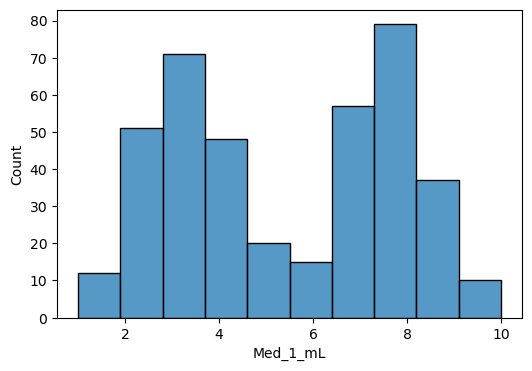

In [8]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Med_1_mL')
plt.show()

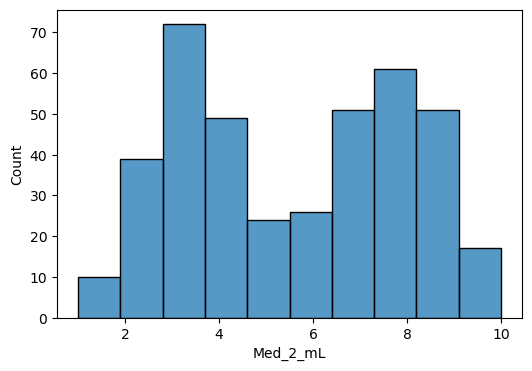

In [9]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'Med_2_mL')
plt.show()

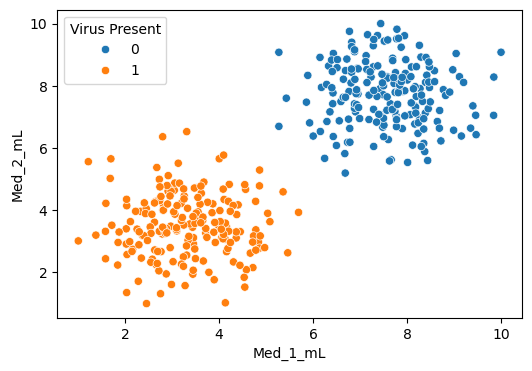

In [10]:
plt.figure(figsize= (6,4))
sns.scatterplot(data= df, x= 'Med_1_mL', y= 'Med_2_mL', hue= 'Virus Present')
plt.show()

- Classes 0 and 1 of Target Variable (Virus Present) are clearly separable as can be seen in the above chart.
- We can expect pretty good results with any classifier on this data.

#### 4) Preprocessing Pipeline:

In [16]:
preprocessor = ColumnTransformer([
    ('Preprocessor', StandardScaler(), ['Med_1_mL', 'Med_2_mL'])
])

#### 5) Train Test Split:

In [12]:
X = df.drop('Virus Present', axis= 1) #Features
y = df['Virus Present'] #Target

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [14]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(320, 2)
(80, 2)
(320,)
(80,)


#### 6) Preprocessing:
- As we are going to try out different models (SVCs with different kernels), we will apply preprocessing separately before model building so as to not do it for each model separately.

In [22]:
X_train_sc = preprocessor.fit_transform(X_train)
X_test_sc = preprocessor.transform(X_test)

#### 6) Models and Evaluation:

- We will Try different Kernel Options and see their outputs.
- The function used below will help us visualize how model is making Hyperplane using different Kernels.
- This function is directly available in SVM official documentation.
    (https://scikit-learn.org/stable/auto_examples/svm/plot_separating_hyperplane.html)

In [15]:
def plot_svm(model,X,y):
    
    X = X.values
    y = y.values
    
    # Scatter Plot
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30,cmap='seismic')

    
    # plot the decision function
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    # plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    # plot support vectors
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k')
    plt.show()

##### 1) Model 1 (Linear Kernel):

In [23]:
model1 = SVC(kernel= 'linear', C= 1) # Model Instance

model1.fit(X_train_sc, y_train) # Fitting The Model

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


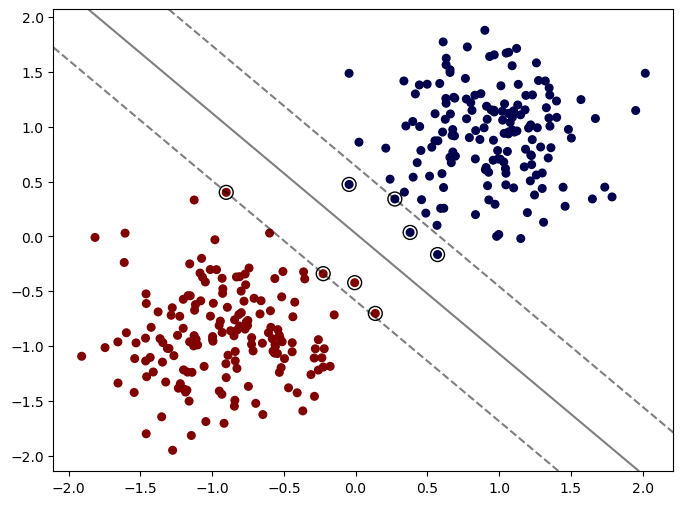

In [26]:
plt.figure(figsize= (8,6), dpi= 100)
plot_svm(model= model1, X= pd.DataFrame(X_train_sc), y= y_train)
plt.show()

##### 2) Model 2 (Linear Kernel):

In [27]:
model2 = SVC(kernel= 'linear', C= 100) # Model Instance
model2.fit(X_train_sc, y_train) # Fitting the model

,C,100
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


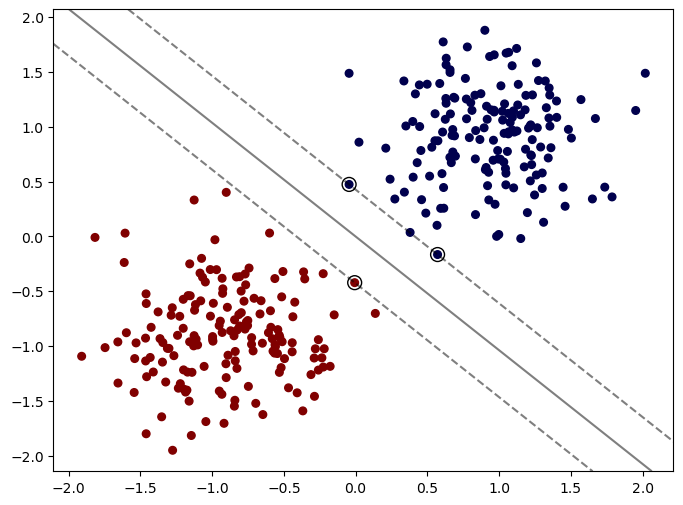

In [28]:
plt.figure(figsize= (8,6), dpi= 100)
plot_svm(model= model2, X= pd.DataFrame(X_train_sc), y= y_train)
plt.show()

##### 3) Model 3 (Linear kernel):

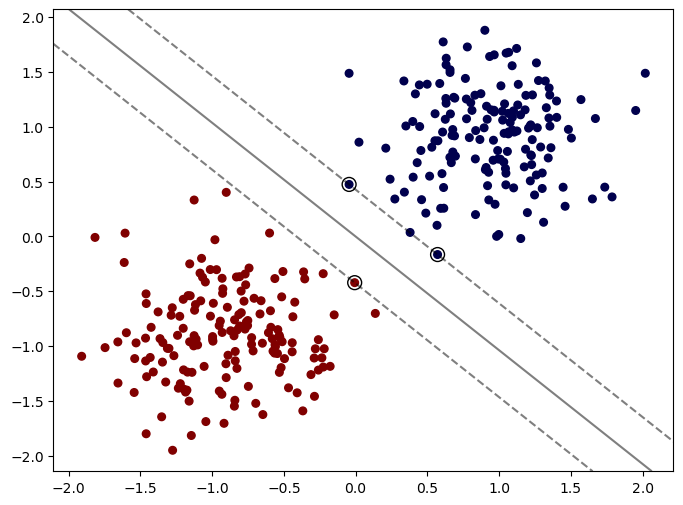

In [29]:
model3 = SVC(kernel= 'linear', C= 1000) # Model Instance
model3.fit(X_train_sc, y_train) # Fitting the model

# Plotiing The Model:
plt.figure(figsize= (8,6), dpi= 100)
plot_svm(model= model3, X= pd.DataFrame(X_train_sc), y= y_train)
plt.show()

##### 4) Model 4 (RBF Kenrel):

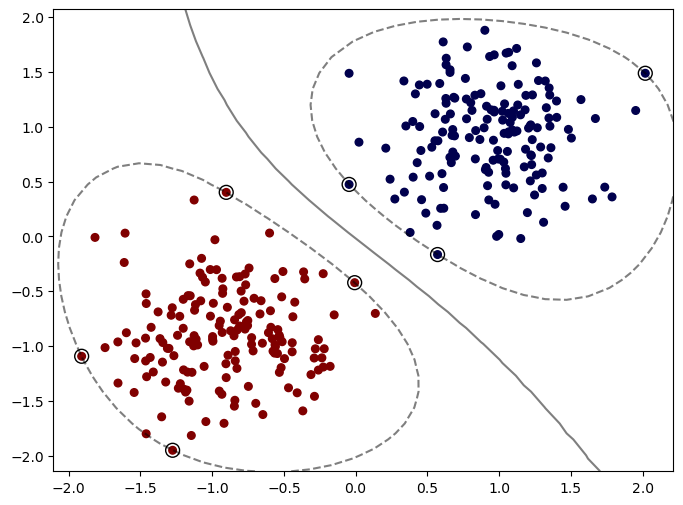

In [30]:
model4 = SVC(kernel= 'rbf', C= 100) # Model Instance
model4.fit(X_train_sc, y_train) # Fitting the model

# Plotiing The Model:
plt.figure(figsize= (8,6), dpi= 100)
plot_svm(model= model4, X= pd.DataFrame(X_train_sc), y= y_train)
plt.show()

##### 5) Model 5 (RBF Kernel):

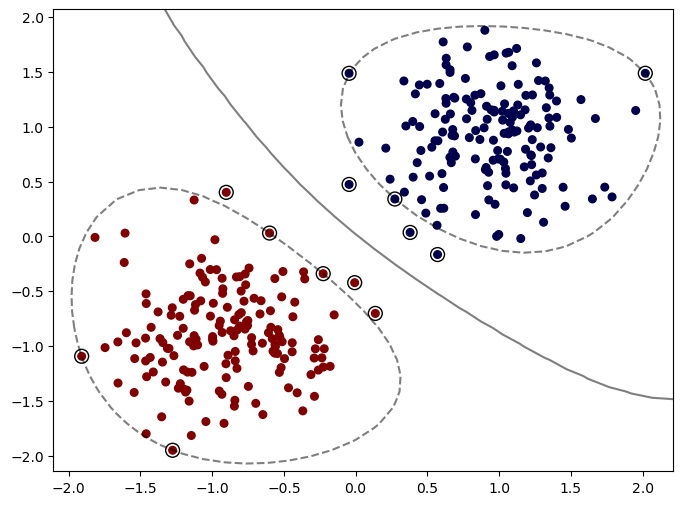

In [31]:
model5 = SVC(kernel= 'rbf', C= 1) # Model Instance
model5.fit(X_train_sc, y_train) # Fitting the model

# Plotiing The Model:
plt.figure(figsize= (8,6), dpi= 100)
plot_svm(model= model5, X= pd.DataFrame(X_train_sc), y= y_train)
plt.show()

##### 6) Model 6 (Polynomial Kernel):

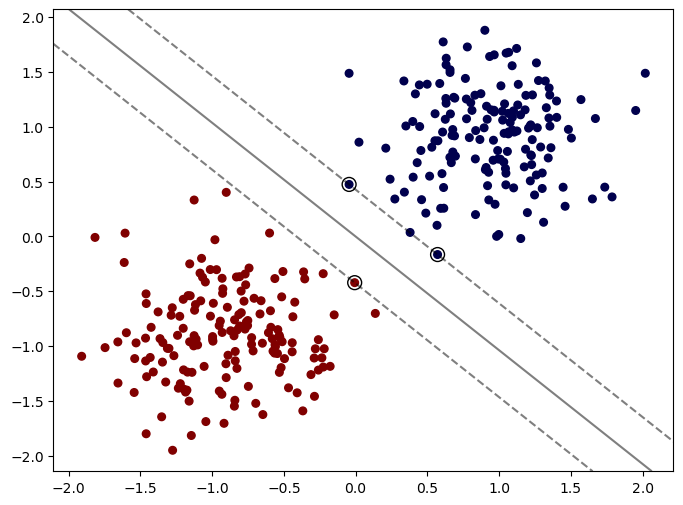

In [32]:
model6 = SVC(kernel= 'poly', C= 100, degree= 1) # Model Instance
model6.fit(X_train_sc, y_train) # Fitting the model

# Plotiing The Model:
plt.figure(figsize= (8,6), dpi= 100)
plot_svm(model= model6, X= pd.DataFrame(X_train_sc), y= y_train)
plt.show()

##### 7) Model 7 (Polynomial Kernel):

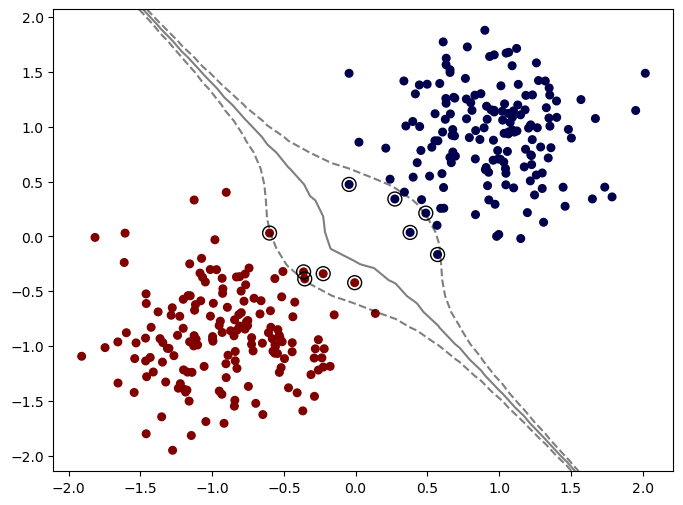

In [33]:
model7 = SVC(kernel= 'poly', C= 100, degree= 3) # Model Instance
model7.fit(X_train_sc, y_train) # Fitting the model

# Plotiing The Model:
plt.figure(figsize= (8,6), dpi= 100)
plot_svm(model= model7, X= pd.DataFrame(X_train_sc), y= y_train)
plt.show()

##### 8) Model 8 (Sigmoid Kernel):

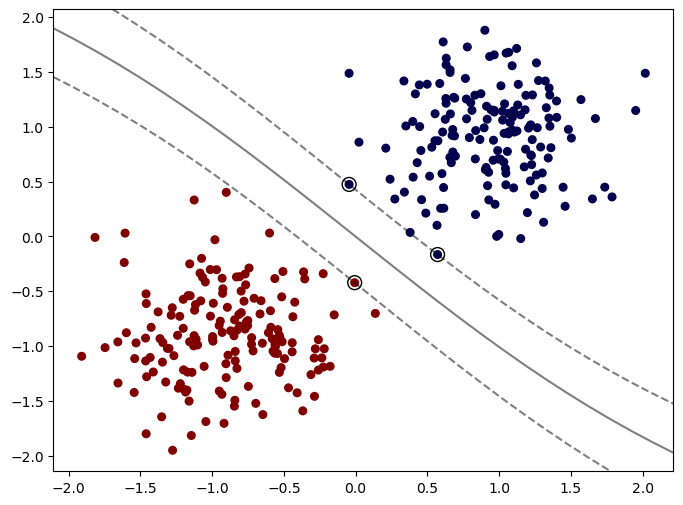

In [34]:
model8 = SVC(kernel= 'sigmoid', C= 100) # Model Instance
model8.fit(X_train_sc, y_train) # Fitting the model

# Plotiing The Model:
plt.figure(figsize= (8,6), dpi= 100)
plot_svm(model= model8, X= pd.DataFrame(X_train_sc), y= y_train)
plt.show()

##### 9) Grid Search on SVC:

In [36]:
model = SVC()

param_dict = {'kernel' : ['linear', 'rbf', 'poly', 'sigmoid'],
             'C' : [0.01, 0,1, 1, 10, 100],
             'degree' : [1,2,3],
            'gamma' : ["scale", "auto"]}

grid_model = GridSearchCV(estimator= model,
                         param_grid= param_dict,
                         cv= 5)

grid_model.fit(X_train_sc, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.01, 0, ...], 'degree': [1, 2, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.01


In [37]:
# Best Estimator and Parameters from Grid:

print(grid_model.best_params_)
print(grid_model.best_score_)

{'C': 0.01, 'degree': 1, 'gamma': 'scale', 'kernel': 'linear'}
1.0


In [38]:
# Predictions Using Best Estimator from Grid:

y_pred = grid_model.predict(X_test_sc)

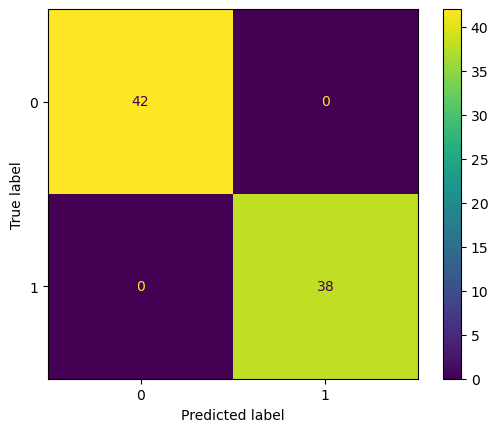

In [39]:
# Confusion Matrix:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels= grid_model.classes_)
disp.plot()
plt.show()

In [40]:
# Classification Report:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       1.00      1.00      1.00        38

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



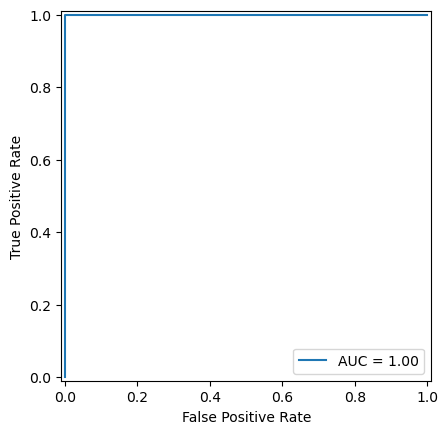

In [41]:
# ROC-AUC Curve:

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
disp = RocCurveDisplay(fpr= fpr, tpr= tpr, roc_auc= roc_auc)
disp.plot()
plt.show()